In [1]:
from mwrogue.esports_client import EsportsClient
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
def get_scoreboard_players_in_tournament(tournament):
    site = EsportsClient("lol")
    response = site.cargo_client.query(
        tables="ScoreboardGames=SG, ScoreboardPlayers=SP, Tournaments=T",
        join_on="SG.GameId=SP.GameId, SG.OverviewPage=T.OverviewPage",
        fields="SP.Name, SP.Champion, SP.Kills, SP.Deaths, SP.Assists, SP.Gold, SP.CS, SP.DamageToChampions, SP.VisionScore, SP.PlayerWin, SP.Role, SP.Team, SP.DateTime_UTC",
        where=f"T.Name = '{tournament}'"
    )
    return pd.DataFrame(response)

In [16]:
msi_sbp = get_scoreboard_players_in_tournament("MSI 2025")

In [27]:
msi_main_sbp = msi_sbp[pd.to_datetime(msi_sbp["DateTime UTC"]) > dt.datetime(2025, 7, 1, 0, 0, 0)]

In [34]:
msi_playin_sbp = msi_sbp[pd.to_datetime(msi_sbp["DateTime UTC"]) <= dt.datetime(2025, 7, 1, 0, 0, 0)]

In [35]:
msi_playin_sbp

,Name,Champion,Kills,Deaths,Assists,Gold,CS,DamageToChampions,VisionScore,PlayerWin,Role,Team,DateTime UTC,DateTime UTC__precision
8,Aress,Ahri,2,5,7,10533,230,18435,25,No,Mid,GAM Esports,2025-06-28 00:57:00,0
9,Aress,Ahri,5,2,4,14859,295,16615,27,Yes,Mid,GAM Esports,2025-06-30 01:51:00,0
10,Aress,LeBlanc,2,2,10,13132,256,25298,25,Yes,Mid,GAM Esports,2025-06-28 21:59:00,0
11,Aress,Orianna,0,3,1,10896,255,14595,24,No,Mid,GAM Esports,2025-06-30 03:37:00,0
12,Aress,Orianna,1,3,13,13369,291,21684,33,Yes,Mid,GAM Esports,2025-06-28 23:38:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,Tutsz,Kassadin,3,2,3,13085,288,14713,46,No,Mid,FURIA,2025-06-28 23:38:00,0
526,Tutsz,Orianna,4,4,10,13676,279,21256,43,No,Mid,FURIA,2025-06-27 21:07:00,0
527,Tutsz,Ryze,3,4,1,14850,355,19021,27,No,Mid,FURIA,2025-06-27 20:00:00,0
528,Tutsz,Sylas,3,0,7,12366,251,13602,26,Yes,Mid,FURIA,2025-06-28 21:02:00,0


<Axes: ylabel='Team'>

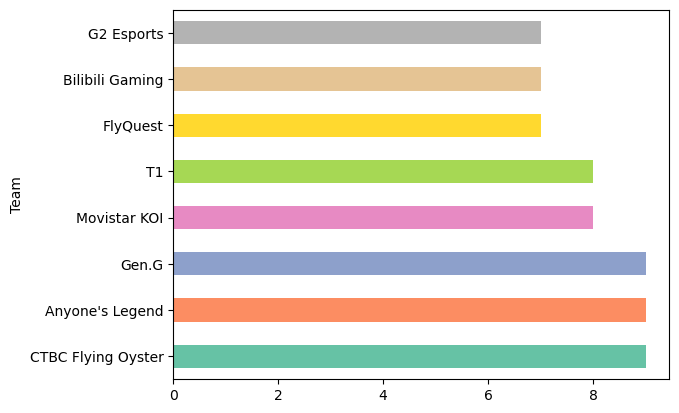

In [33]:
(msi_main_sbp["Team"].value_counts()/5).plot(kind="barh", color=sns.color_palette("Set2", n_colors=8))